In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.stats import wilcoxon, norm, sem
import matplotlib.patches as mpatches
import matplotlib.lines as mlines



In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [3]:
war_date = pd.to_datetime("2022-02-24")

exclude = [
    "06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f",
    "179bbc95-ec8b-4a65-98c5-5d3b566806fa"
]

activity_col = ["text_count", "audio_count", "reaction_count", "comment_count", "post_count"]


In [4]:
base = filtered_data / ""

df_text = pd.read_csv(base / "text_messages_filtered.csv")
df_audio = pd.read_csv(base / "audio_messages_filtered.csv")
df_react = pd.read_csv(base / "reactions_sorted.csv")
df_comm = pd.read_csv(base / "comments_sorted.csv")
df_post = pd.read_csv(base / "posts_sorted.csv")

df_text["datetime"] = pd.to_datetime(df_text["datetime"])
df_audio["datetime"] = pd.to_datetime(df_audio["datetime"])
df_react["datetime"] = pd.to_datetime(df_react["datetime"])
df_comm["datetime"] = pd.to_datetime(df_comm["datetime"])
df_post["datetime"] = pd.to_datetime(df_post["datetime"])

df_text = df_text[df_text["is_donor"] == 1]
df_audio = df_audio[df_audio["is_donor"] == 1]

for d in [df_text, df_audio, df_react, df_comm, df_post]:
    d["date"] = d["datetime"].dt.date
    d["hour"] = d["datetime"].dt.hour
    d.drop(d[d["donation_id"].isin(exclude)].index, inplace=True)


In [5]:
configs = [
    (df_text, "text_count"),
    (df_audio, "audio_count"),
    (df_react, "reaction_count"),
    (df_comm, "comment_count"),
    (df_post, "post_count"),
]

hourly_dfs = [
    df.groupby(["donation_id", "date", "hour"])
      .size().reset_index(name=col)
    for df, col in configs
]

df_hourly = reduce(
    lambda l, r: pd.merge(l, r, on=["donation_id", "date", "hour"], how="outer"),
    hourly_dfs
).fillna(0)


In [6]:
unique_pairs = df_hourly[["donation_id", "date"]].drop_duplicates()
all_hours = unique_pairs.merge(pd.DataFrame({"hour": range(24)}), how="cross")

df_hourly = all_hours.merge(df_hourly, on=["donation_id", "date", "hour"], how="left")
df_hourly[activity_col] = df_hourly[activity_col].fillna(0)
df_hourly["active"] = (df_hourly[activity_col].sum(axis=1) > 0).astype(int)
df_hourly = df_hourly.sort_values(["donation_id", "date", "hour"]).reset_index(drop=True)
df_hourly["date"] = pd.to_datetime(df_hourly["date"])

print(f"Rows: {len(df_hourly):,}")
print(f"Active hours: {df_hourly['active'].sum():,}")


Rows: 864,696
Active hours: 203,103


In [7]:
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

pre = df_hourly[(df_hourly["date"] >= pre_start) & (df_hourly["date"] <  war_date)]
post = df_hourly[(df_hourly["date"] >= war_date) & (df_hourly["date"] <= post_end)]

print(f'Pre: {pre["date"].min().date()} → {pre["date"].max().date()} ({pre["date"].nunique()} days)')
print(f'Post: {post["date"].min().date()} → {post["date"].max().date()} ({post["date"].nunique()} days)')


Pre: 2021-08-24 → 2022-02-23 (184 days)
Post: 2022-02-24 → 2022-08-24 (182 days)



#### Change in hourly activity distribution (post − pre)

In [8]:
def get_diff(donor_id, activity_group):
    mapping = {
        "private": ["text_count", "audio_count"],
        "public":  ["reaction_count", "comment_count", "post_count"],
    }
    cols = mapping[activity_group]

    def get_dist(df_period):
        d = df_period[df_period["donation_id"] == donor_id]
        if d.empty:
            return None
        hourly = d.groupby("hour")[cols].sum().sum(axis=1).reindex(range(24), fill_value=0)
        total = hourly.sum()
        if total == 0:
            return None
        return hourly / total

    before_dist = get_dist(pre)
    after_dist = get_dist(post)

    if before_dist is None or after_dist is None:
        return None
    return after_dist - before_dist


In [9]:
def get_avg_diff(activity_group):
    diffs = []
    for donor_id in df_hourly["donation_id"].unique():
        d = get_diff(donor_id, activity_group)
        if d is not None:
            diffs.append(d)
    diffs_df = pd.DataFrame(diffs)
    return diffs_df.mean(), sem(diffs_df, axis=0)

In [10]:
def plot_diff(diff, title, se=None):
    colors = ["tomato" if v > 0 else "steelblue" for v in diff]
    plt.figure(figsize=(10, 4))
    plt.bar(diff.index, diff.values, color=colors)
    if se is not None:
        plt.errorbar(diff.index, diff.values, yerr=se,
                     fmt='none', color='black', capsize=3, linewidth=1)
    plt.axhline(0, color="black")
    plt.title(title)
    plt.xlabel("Hour of day")
    plt.ylabel("Δ (post − pre)")
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()

#### Hourly activity distribution — pre vs post (line plot)

In [11]:
def get_avg_dist(activity_group):
    mapping = {
        "private": ["text_count", "audio_count"],
        "public":  ["reaction_count", "comment_count", "post_count"],
    }
    cols = mapping[activity_group]

    pre_dists, post_dists = [], []

    for donor_id in df_hourly["donation_id"].unique():
        for df_period, store in [(pre, pre_dists), (post, post_dists)]:
            d = df_period[df_period["donation_id"] == donor_id]
            if d.empty:
                continue
            hourly = d.groupby("hour")[cols].sum().sum(axis=1).reindex(range(24), fill_value=0)
            total = hourly.sum()
            if total == 0:
                continue
            store.append(hourly / total)

    pre_df  = pd.DataFrame(pre_dists)
    post_df = pd.DataFrame(post_dists)

    return pre_df.mean(), post_df.mean(), sem(pre_df, axis=0), sem(post_df, axis=0)


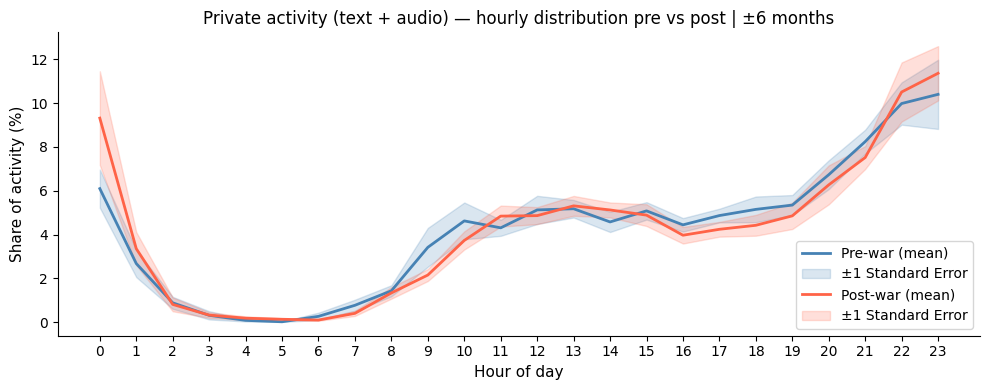

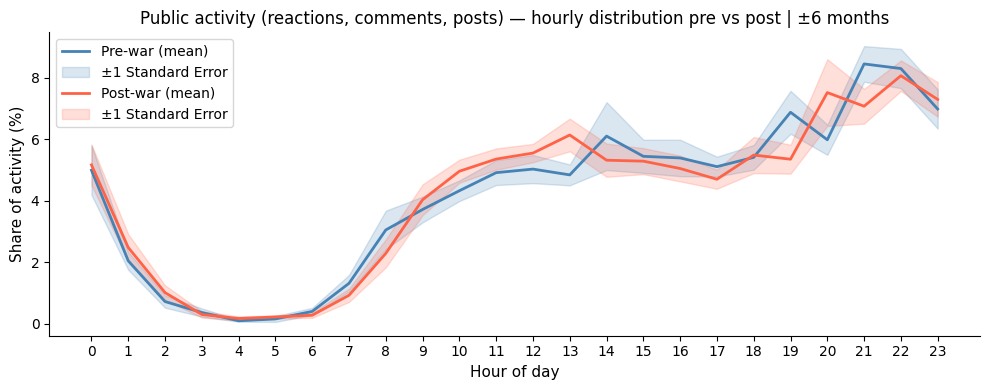

In [12]:
for activity_group, title in [
    ("private", "Private activity (text + audio)"),
    ("public",  "Public activity (reactions, comments, posts)"),
]:
    pre_mean, post_mean, pre_se, post_se = get_avg_dist(activity_group)
    hours = range(24)

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(hours, pre_mean * 100,  color="steelblue", linewidth=2)
    ax.fill_between(hours,
                    (pre_mean - pre_se) * 100,
                    (pre_mean + pre_se) * 100,
                    alpha=0.2, color="steelblue")

    ax.plot(hours, post_mean * 100, color="tomato", linewidth=2)
    ax.fill_between(hours,
                    (post_mean - post_se) * 100,
                    (post_mean + post_se) * 100,
                    alpha=0.2, color="tomato")

    pre_line  = mlines.Line2D([], [], color="steelblue", linewidth=2, label="Pre-war (mean)")
    pre_se_p  = mpatches.Patch(color="steelblue", alpha=0.2, label="±1 Standard Error")
    post_line = mlines.Line2D([], [], color="tomato", linewidth=2, label="Post-war (mean)")
    post_se_p = mpatches.Patch(color="tomato", alpha=0.2, label="±1 Standard Error")

    ax.set_xlabel("Hour of day", fontsize=11)
    ax.set_ylabel("Share of activity (%)", fontsize=11)
    ax.set_title(f"{title} — hourly distribution pre vs post | ±6 months", fontsize=12)
    ax.set_xticks(range(24))
    ax.legend(handles=[pre_line, pre_se_p, post_line, post_se_p], fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

#### Average hourly delta across all donors

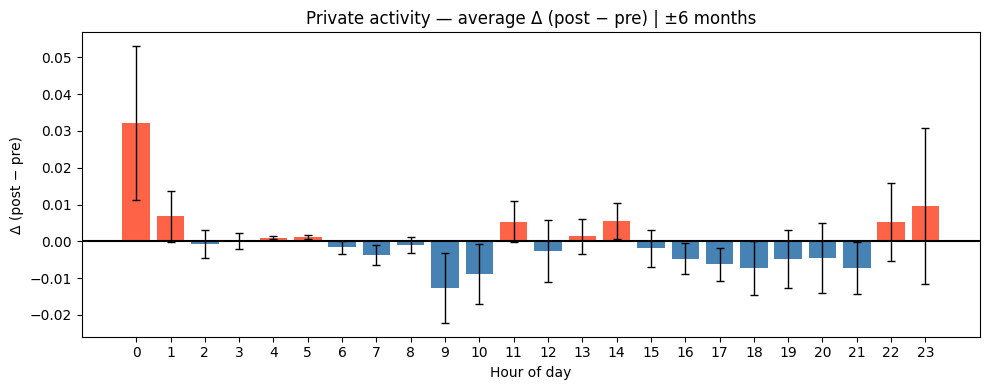

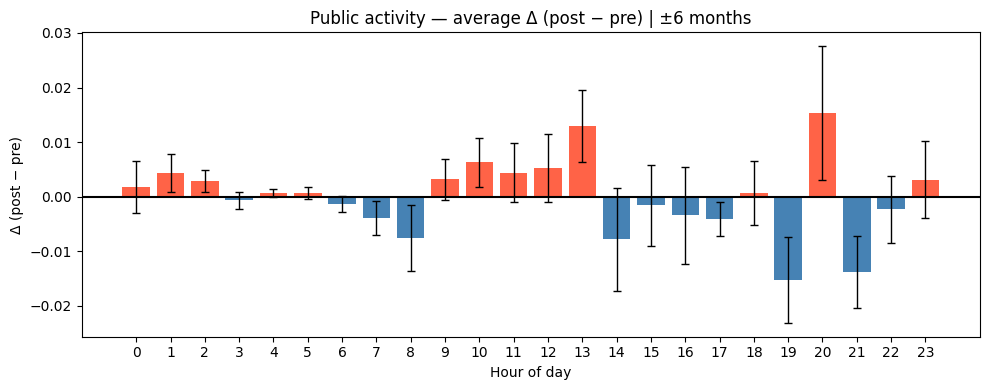

In [13]:
private_avg, private_se = get_avg_diff("private")
public_avg, public_se  = get_avg_diff("public")

plot_diff(private_avg, "Private activity — average Δ (post − pre) | ±6 months", se=private_se)
plot_diff(public_avg, "Public activity — average Δ (post − pre) | ±6 months", se=public_se)


#### Hourly activity concentration (Gini index)

In [14]:
def gini_hourly(values):
    arr = np.array(values, dtype=float)
    if arr.sum() == 0:
        return np.nan
    arr = np.sort(arr)
    n = len(arr)
    return (2 * np.sum(np.arange(1, n+1) * arr) / (n * arr.sum())) - (n+1)/n


In [15]:
results = []

for donor_id in df_hourly["donation_id"].unique():
    for period, df_p in [("pre", pre), ("post", post)]:
        d = df_p[df_p["donation_id"] == donor_id]
        if d.empty:
            continue

        hourly = d.groupby("hour").agg(
            private=("text_count", "sum"),
            public= ("reaction_count", "sum"),
        ).reindex(range(24), fill_value=0)

        hourly["private"] += d.groupby("hour")["audio_count"].sum().reindex(range(24), fill_value=0)
        hourly["public"] += d.groupby("hour")["comment_count"].sum().reindex(range(24), fill_value=0)
        hourly["public"] += d.groupby("hour")["post_count"].sum().reindex(range(24), fill_value=0)

        results.append({
            "donation_id": donor_id,
            "period": period,
            "gini_private": gini_hourly(hourly["private"].values),
            "gini_public": gini_hourly(hourly["public"].values),
        })

gini_hourly_df = pd.DataFrame(results)
gini_pre = gini_hourly_df[gini_hourly_df["period"] == "pre"]
gini_post = gini_hourly_df[gini_hourly_df["period"] == "post"]
print(f"Donors: {gini_hourly_df['donation_id'].nunique()}")


Donors: 22


#### Gini distribution pre vs post

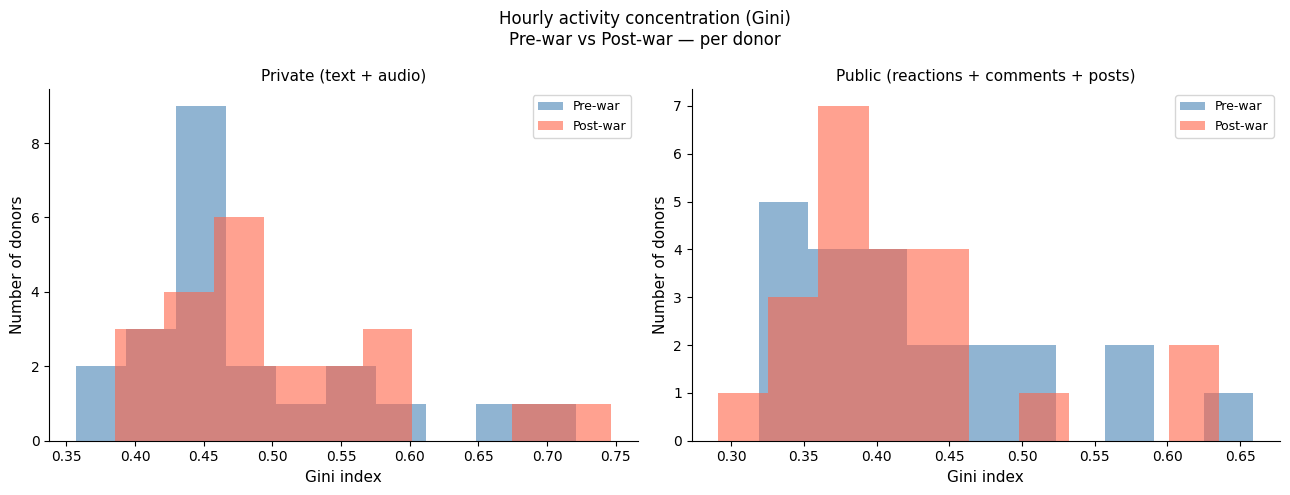

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "gini_private", "Private (text + audio)"),
    (axes[1], "gini_public", "Public (reactions + comments + posts)"),
]:
    ax.hist(gini_pre[col].dropna(), bins=10, alpha=0.6, color="steelblue", label="Pre-war")
    ax.hist(gini_post[col].dropna(), bins=10, alpha=0.6, color="tomato", label="Post-war")
    ax.set_xlabel("Gini index", fontsize=11)
    ax.set_ylabel("Number of donors", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Hourly activity concentration (Gini)\nPre-war vs Post-war — per donor", fontsize=12)
plt.tight_layout()
plt.show()


#### Wilcoxon signed-rank (Gini pre vs post)

In [17]:
merged = gini_pre.merge(
    gini_post, on="donation_id", suffixes=("_pre", "_post")
).dropna()

print("Wilcoxon Signed-Rank Test — Gini (hourly)")
print(f"n = {len(merged)} donors\n")

for col, label in [("gini_private", "Private"), ("gini_public", "Public")]:
    pre_vals  = merged[f"{col}_pre"].values
    post_vals = merged[f"{col}_post"].values
    stat, p = wilcoxon(pre_vals, post_vals)
    r = abs(norm.ppf(p / 2)) / np.sqrt(len(pre_vals))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    direction = "more dispersed" if post_vals.mean() < pre_vals.mean() else "more concentrated"
    print(f"{label}:")
    print(f"  Mean pre: {pre_vals.mean():.4f}")
    print(f"  Mean post: {post_vals.mean():.4f}")
    print(f"  W = {stat:.1f}, p = {p:.4f} {sig}, r = {r:.3f} → {direction} after war\n")


Wilcoxon Signed-Rank Test — Gini (hourly)
n = 22 donors

Private:
  Mean pre: 0.4814
  Mean post: 0.5060
  W = 83.0, p = 0.1659 n.s., r = 0.295 → more concentrated after war

Public:
  Mean pre: 0.4240
  Mean post: 0.4169
  W = 120.0, p = 0.8486 n.s., r = 0.041 → more dispersed after war



#### Hourly activity share per donor 

In [18]:
activity = ["text_count", "audio_count"]  # private

donor_ids = []
matrix_pre = []
matrix_post = []

for donor_id in df_hourly["donation_id"].unique():
    d_pre  = pre[pre["donation_id"] == donor_id]
    d_post = post[post["donation_id"] == donor_id]

    if d_pre.empty or d_post.empty:
        continue

    hourly_pre = d_pre.groupby("hour")[activity].sum().sum(axis=1).reindex(range(24), fill_value=0)
    hourly_post = d_post.groupby("hour")[activity].sum().sum(axis=1).reindex(range(24), fill_value=0)

    if hourly_pre.sum() == 0 or hourly_post.sum() == 0:
        continue

    matrix_pre.append(hourly_pre / hourly_pre.sum())
    matrix_post.append(hourly_post / hourly_post.sum())
    donor_ids.append(donor_id[:6])

matrix_pre = np.array(matrix_pre)
matrix_post = np.array(matrix_post)
delta_heatmap = matrix_post - matrix_pre

print(f"Donors: {len(donor_ids)}, shape: {delta_heatmap.shape}")


Donors: 22, shape: (22, 24)


#### Heatmap pre / post / delta per donor

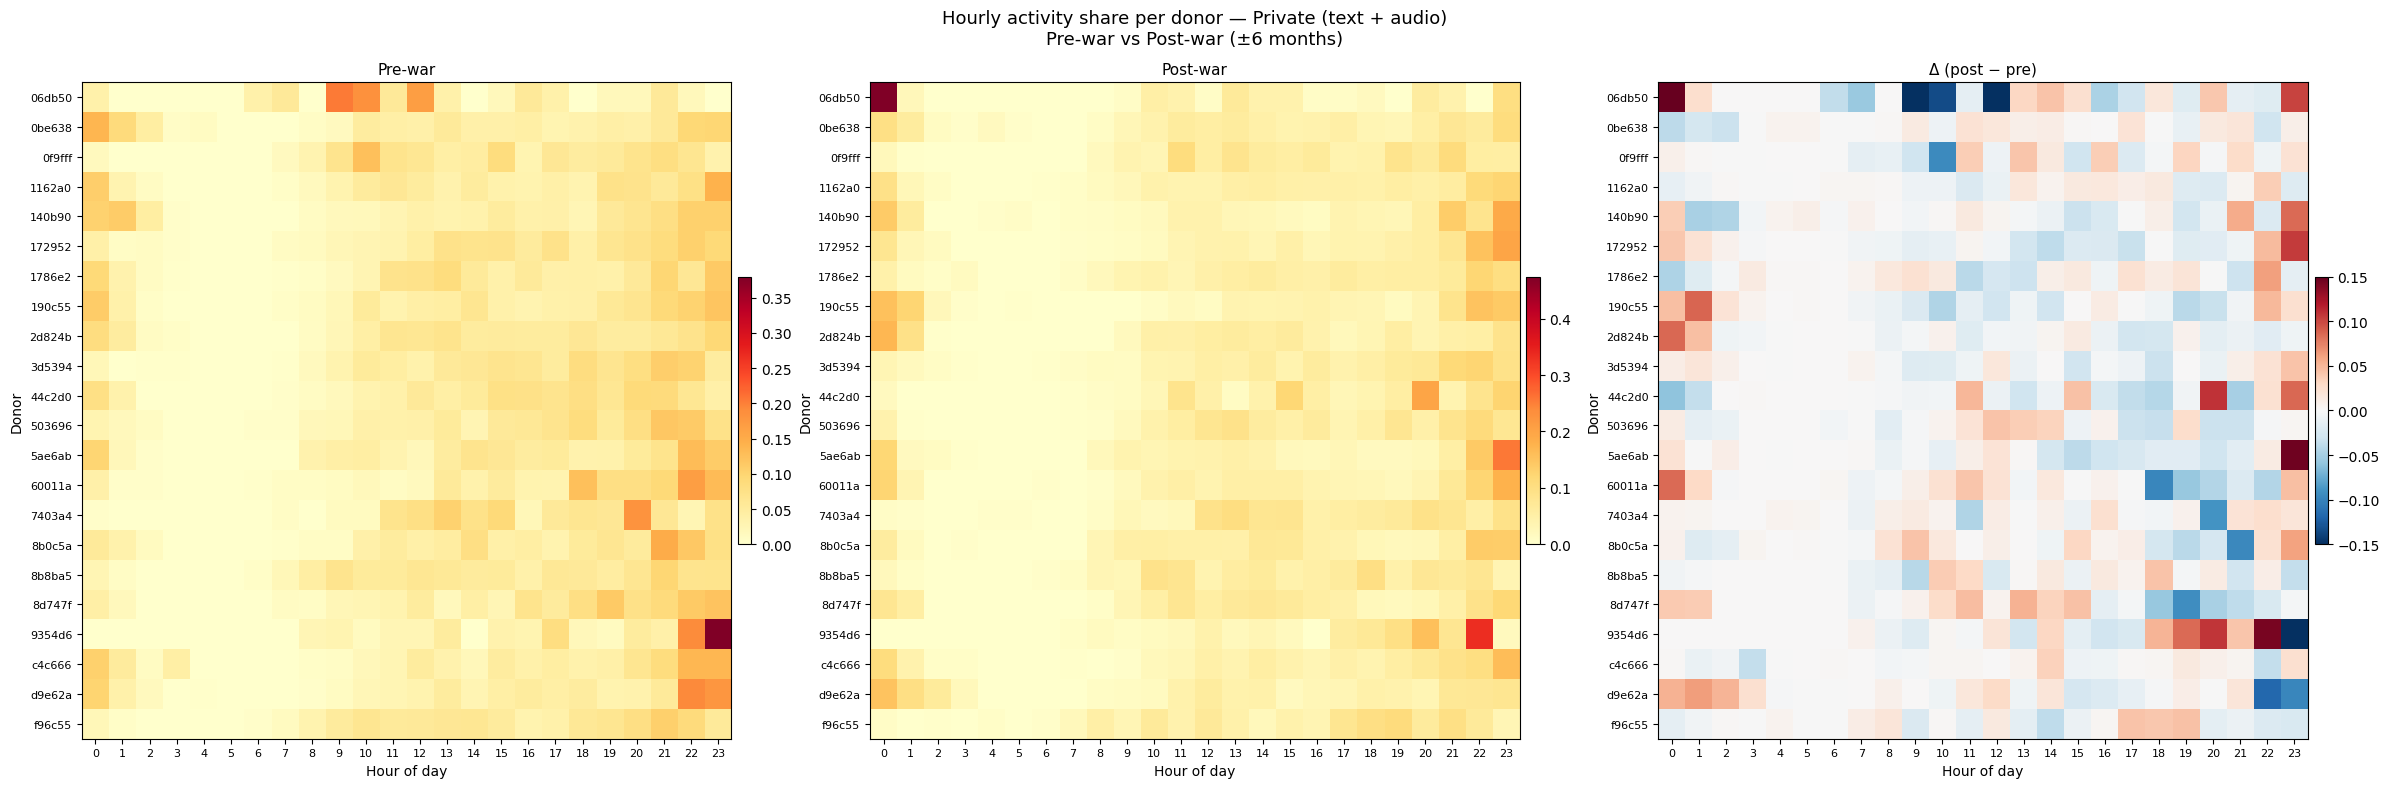

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

titles = ["Pre-war", "Post-war", "Δ (post − pre)"]
matrices = [matrix_pre, matrix_post, delta_heatmap]
cmaps = ["YlOrRd", "YlOrRd", "RdBu_r"]

for ax, mat, title, cmap in zip(axes, matrices, titles, cmaps):
    vmin = -0.15 if title == "Δ (post − pre)" else 0
    vmax =  0.15 if title == "Δ (post − pre)" else mat.max()
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    ax.set_yticks(range(len(donor_ids)))
    ax.set_yticklabels(donor_ids, fontsize=8)
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=8)
    ax.set_xlabel("Hour of day", fontsize=10)
    ax.set_ylabel("Donor", fontsize=10)
    ax.set_title(title, fontsize=11)

plt.suptitle("Hourly activity share per donor — Private (text + audio)\nPre-war vs Post-war (±6 months)",
             fontsize=13)
plt.tight_layout()
plt.show()
